# Monitoring zmian wód powierzchniowych na podstawie danych Sentinel-2

Niniejszy notebook stanowi kompletny przewodnik krok po kroku, pokazujący jak wykorzystać publicznie dostępne dane satelitarne oraz interfejs STAC do analizy zmian powierzchni zbiorników wodnych w czasie.
  
Notebook krok po kroku pokazuje proces:
1. wyszukania zobrazowań satelitarnych,
2. pobrania danych spektralnych,
3. obliczenia wskaźnika NDWI,
4. wyznaczenia powierzchni wody,
5. wizualizacji oraz interpretacji wyników.

Analiza zmian powierzchni wody została wykonana dla zbiornika wodnego Asprokremmos położonego na Cyprze. Użyto trzech okresów czasowych obejmujących dni od początku maja do początku czerwca w latach 2020, 2023 i 2025. Zaleca się dostosowanie okresów do potrzeb Twojego projektu.

## Krok 0. Zainstalowanie i import bibliotek

Przy pracy z dużymi i złożonymi danymi – takimi jak zdjęcia satelitarne – kluczowe jest wykorzystanie odpowiednich bibliotek Pythona. Poniższy przykład łączy standardowe narzędzia do analizy danych ze specjalistycznymi pakietami GIS:

* `arcpy` - biblioteka służąca do automatyzacji zadań GIS, analizy przestrzennej, konwersji oraz zarządzania danymi ArcGIS. To podstawowe narzędzie do wykonywania prostych i bardziej skomplikowanych operacji przestrzennych. Dodatkowo, moduł Image Analysis `ia` pozwala na automatyzację przetwarzania danych rastrowych.
* `itertools` - moduł, który udostępnia zbiór szybkich i wydajnych narzędzi do tworzenia i obsługi iteratorów, do przetwarzania strumieni danych bez zapisywania w pamięci RAM.
* `os` - moduł pozwalający na wchodzenie w interakcję z systemem operacyjnym do obsługi ścieżek plików i folderów.
* `numpy` - biblioteka do zaawansowanych obliczeń numerycznych i naukowych, przetwarzania dużych zbiorów danych, macierzy i wielowymiarowych tablic.
* `pandas` - biblioteka do przetwarzania i manipulowania danymi, filtrowanie i agregowanie wierszy dużych zbiorów danych.
* `matplotlib` - biblioteka służąca do wizualizacji danych oraz tworzenia wykresów, do czego wykorzystywany jest moduł `pyplot`.
* `pystac_client` - biblioteka służąca do wyszukiwania, przeglądania i pobierania danych geoprzestrzennych, takich jak Sentinel czy Landsat, za pośrednictwem interfejsów API zgodnie ze standardem STAC.
* `scipy` - biblioteka również wykorzystywana do obliczeń numerycznych, w tym przypadku do wielowymiarowego przetwarzania obrazów.
  
Przed rozpoczęciem analizy, należy przygotować odpowiednie środowisko. Najprościej jest to zrobić przez skopiowanie domyślnego środowiska ArcGIS Pro i doinstalowanie do niego brakujących bibliotek.  
Można to zrobić bezpośrednio w dedykowanej konsoli Python Command Prompt (ważne, żeby uruchomić ją z poziomu systemu, a nie jako zwykły terminal!), klonując bazowe środowisko za pomocą komendy:
```{bash}
conda create --clone arcgispro-py3 --name nazwa_srodowiska --pinned
```
  
Brakującą bibliotekę (w przypadku tego projektu: `pystac-client`) należy doinstalować po aktywacji środowiska bezpośrednio w Notebooku poprzez wykonanie poniższej komórki:

In [1]:
# %pip install pystac-client

In [2]:
import arcpy
import itertools
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arcpy.ia import *
from arcpy.ia import Clip as iaClip
from pystac_client import Client
from scipy import ndimage

## Krok 1. Zdefiniuj obszar i okres analizy

Każda analiza zmian powierzchni wody wymaga określenia:

- obszaru zainteresowania (AOI),
- okresów czasowych, które chcemy porównać,
- maksymalnego dopuszczalnego zachmurzenia.

**Obszar zainteresowania**  
Jest to teren, który chcemy poddać analizie. Dobieramy go za pomocą zmiennej `bbox`, gdzie podawane są 4 współrzędne w układzie *WGS 84*, w formacie stopni dziesiętnych.
Ważna jest kolejność podawanych danych, ponieważ przedstawiają one (w podanej kolejności) - zachodnią, południową, wschodnią oraz północną wartość ograniczającą pole działania.

<div style="display: grid; grid-template-columns: 120px 240px 120px 200px; grid-template-rows: 60px 120px 60px; justify-items: center; align-items: center; font-family: sans-serif; gap: 15px;">
  
  <div style="grid-column: 2; grid-row: 1; text-align: center;"><strong>MaxLat</strong><br>Północ</div>
  
  <div style="grid-column: 1; grid-row: 2; text-align: center;"><strong>MinLon</strong><br>Zachód</div>
  
  <div style="grid-column: 2; grid-row: 2; border: 2px solid #f5f5f5; padding: 20px; border-radius: 8px; text-align: center; width: 100%; box-sizing: border-box;">
    <strong>Zasięg analizy</strong>
  </div>
  
  <div style="grid-column: 3; grid-row: 2; text-align: center;"><strong>MaxLon</strong><br>Wschód</div>
  
  <div style="grid-column: 2; grid-row: 3; text-align: center;"><strong>MinLat</strong><br>Południe</div>

  <div style="grid-column: 5; grid-row: 2; padding: 15px; border-radius: 8px; font-family: monospace;">
    <strong>bbox = [</strong><br>
    &nbsp MinLon, MinLat, MaxLon, MaxLat<br>
    <strong>]</strong>
  </div>

</div>

**Zakres czasowy**  
Zakresy zapytań data_range określają przedział czasowy „od–do” i są zapisywane przy użyciu ukośnika, gdzie cała data przed znakiem / to moment rozpoczęcia wyszukiwania, a data po znaku / to moment jego zakończenia. Obie daty podaje się w uniwersalnym formacie rok-miesiąc-dzieńTgodzina:minuta:sekundaZ, w którym litera „T” oddziela dzień od godziny, a „Z” oznacza uniwersalną strefę czasową (UTC), co pozwala wyszukiwarce STAC przefiltrować zdjęcia satelitarne wykonane dokładnie pomiędzy tymi dwoma wskazanymi momentami.

**Maksymalne zachmurzenie**  
Ponieważ analiza opiera się na świetle odbitym od ziemi, chmury i ich cienie mogą całkowicie zasłonić badany zbiornik i utrudnić obliczenia. Parametr `max_cloud_cover` pozwala odrzucić zdjęcia o zbyt dużej obecności chmur w kadrze. Ustawienie parametru na poziomie **5%** oznacza, że system wybierze tylko te sceny, na których chmury zajmują maksymalnie pięć procent powierzchni zdjęcia.

<div style="background-color:rgb(250, 227, 152); border-left: 10px solidrgb(245, 215, 124); padding: 10px 30px; border-radius: 4px; color: #856404; font-family: sans-serif;">
<strong>Uwaga</strong><br>
Należy pamiętać, że wybrane wartości mają bezpośredni wpływ na czas oraz wynik przetwarzania. 
<li>Zbyt duży obszar może znacząco wydłużyć wyliczanie współczynnika!</li>
<li>Zbyt wąski zakres dat może uniemożliwić znalezienie pasujących zobrazowań!</li>
<li>Zbyt wysoki procent zachmurzenia może uniemożliwić przeprowadzenie analizy!</li>
</div>
  
W przykładzie analizowany jest zbiornik *Asprokremmos* w południowo-zachodniej części Cypru. Jest to sztuczny zbiornik wodny otwarty w 1982 r. zasilany wysychającą rzeką *Xeropotamos* (grec. "Sucha Rzeka"). Z powodu niskich opadów w suchej porze letniej zbiornik traci znaczące ilości wody zebranej w czasie wiosennej pory opadowej. Sytuację utrudnia trwająca od wielu lat susza hydrologiczna i nieregularne opady na przełomie zimy oraz w czasie wiosny. Prowadzi to do znacznego zróżnicowania poziomu wody na przestrzeni kolejnych lat.

Podany obszar jest przykładem ilustrującym działanie notatnika wyliczającego współczynnik NDWI, jednak użytkownik może podstawić własny zbiornik, zmieniając współrzędne BBOX oraz zakresy dat.

W kolejnej komórce definiujemy wszystkie parametry sterujące analizą.

In [3]:
# bounding box dla zbiornika Asprokremmos
bbox = [32.53, 34.724685, 32.578648, 34.762221] 

# zakresy dla zapytań STAC
date_range_1 = "2020-05-01T00:00:00Z/2020-06-01T23:59:59Z"
date_range_2 = "2023-05-01T00:00:00Z/2023-06-01T23:59:59Z"
date_range_3 = "2025-05-01T00:00:00Z/2025-06-01T23:59:59Z"

# maksymalne pokrycie chmur
max_cloud_cover = 5

# Krok 2. Wyszukaj odpowiednie zobrazowania satelitarne

Aby porównać zmiany powierzchni wody, potrzebujemy obrazów satelitarnych wykonanych w różnych okresach.

Dla tego przykładu warto wybrać sceny:
- o niskim zachmurzeniu,
- wykonane w podobnej porze roku,
- obejmujące cały analizowany obszar.
  
W tym przykładzie dla każdego okresu wyszukujemy jedną scenę Sentinel-2 spełniającą zadane kryteria.

Dane **Sentinel-2 (Level-2A)** wykorzystują sensor **MSI**, który dostarcza zdjęcia w 13 pasmach spektralnych o rozdzielczości do **10 metrów**. Produkt ten jest automatycznie korygowany atmosferycznie, co pozwala na bezpośrednią analizę odbicia światła od powierzchni terenu (*Surface Reflectance*).

Dzięki **5-dniowemu cyklowi rewizyty** satelitów możliwe jest regularne monitorowanie zmian poziomu wód.

In [4]:
# inicjalizacja klienta STAC (Earth Search AWS)
catalog = Client.open("https://earth-search.aws.element84.com/v1")

# słownik do przechowywania wyników wyszukiwania dla kolejnych okresów
queries = {"scena_2020": date_range_1, 
           "scena_2023": date_range_2,
           "scena_2025": date_range_3}

all_assets_rows = []
found_scene_ids = []

# pętla iterująca po okresach czasowych
for period_name, date_range in queries.items():
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=date_range,
        query={"eo:cloud_cover": {"lt": max_cloud_cover}},
        max_items=1,  # pobieramy 1 najlepsze zdjęcie
    )

    item = list(search.items())[0]
    found_scene_ids.append(item.id)

    print(
        f"znaleziona scena dla {period_name}: ID: {item.id}, data: {item.datetime}, zachmurzenie: {item.properties.get('eo:cloud_cover')}%"
    )

    # ekstrakcja metadanych assetów (pasm) dla znalezionej sceny
    for asset_key, asset in item.assets.items():
        extra = asset.extra_fields

        eo_bands = extra.get("eo:bands", [])
        raster_bands = extra.get("raster:bands", [])

        all_assets_rows.append(
            {
                "okres": period_name,
                "scene_id": item.id,
                "asset_key": asset_key,
                "title": asset.title,
                "media_type": asset.media_type,
                "href": asset.href,
                "eo_band_names": [b.get("name") for b in eo_bands],
                "eo_common_names": [
                    b.get("common_name") for b in eo_bands
                ],
                "eo_centers": [b.get("center_wavelength") for b in eo_bands],
                "raster_bands": raster_bands,
            }
        )

znaleziona scena dla scena_2020: ID: S2A_36SVD_20200528_1_L2A, data: 2020-05-28 08:40:42.547000+00:00, zachmurzenie: 4.230241%
znaleziona scena dla scena_2023: ID: S2A_36SVD_20230503_0_L2A, data: 2023-05-03 08:40:36.818000+00:00, zachmurzenie: 0.125049%
znaleziona scena dla scena_2025: ID: S2A_36SVD_20250524_0_L2A, data: 2025-05-24 08:40:53.138000+00:00, zachmurzenie: 3.748558%


# Krok 3. Sprawdź metadane znalezionych scen

Przed rozpoczęciem analizy warto zweryfikować:
- datę wykonania zobrazowania,
- poziom zachmurzenia,
- dostępne pasma spektralne,
- identyfikatory scen.

Dzięki temu mamy pewność, że dane nadają się do dalszego przetwarzania i powinniśmy je pobrać.

In [14]:
# tworzenie zbiorczego DataFrame
assets_df = pd.DataFrame(all_assets_rows)

# wyświetlenie najważniejszych kolumn
display_cols = [
    "okres",
    "scene_id",
    "asset_key",
    "title",
    "eo_band_names",
    "eo_common_names",
    "eo_centers",
    "media_type",
    "href"
]

assets_df_filtered = assets_df[display_cols]
assets_df_filtered.head(35)

,okres,scene_id,asset_key,title,eo_band_names,eo_common_names,eo_centers,media_type,href
0,scena_2020,S2A_36SVD_20200528_1_L2A,aot,Aerosol optical thickness (AOT),[],[],[],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
1,scena_2020,S2A_36SVD_20200528_1_L2A,blue,Blue (band 2) - 10m,[blue],[blue],[0.49],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
2,scena_2020,S2A_36SVD_20200528_1_L2A,coastal,Coastal aerosol (band 1) - 60m,[coastal],[coastal],[0.443],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
3,scena_2020,S2A_36SVD_20200528_1_L2A,granule_metadata,NaN,[],[],[],application/xml,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
4,scena_2020,S2A_36SVD_20200528_1_L2A,green,Green (band 3) - 10m,[green],[green],[0.56],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
5,scena_2020,S2A_36SVD_20200528_1_L2A,nir,NIR 1 (band 8) - 10m,[nir],[nir],[0.842],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
6,scena_2020,S2A_36SVD_20200528_1_L2A,nir08,NIR 2 (band 8A) - 20m,[nir08],[nir08],[0.865],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
7,scena_2020,S2A_36SVD_20200528_1_L2A,nir09,NIR 3 (band 9) - 60m,[nir09],[nir09],[0.945],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
8,scena_2020,S2A_36SVD_20200528_1_L2A,red,Red (band 4) - 10m,[red],[red],[0.665],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
9,scena_2020,S2A_36SVD_20200528_1_L2A,rededge1,Red edge 1 (band 5) - 20m,[rededge1],[rededge],[0.704],image/tiff; application=geotiff; profile=cloud...,https://sentinel-cogs.s3.us-west-2.amazonaws.c...


# Krok 4. Pobierz wybrane sceny

Po znalezieniu odpowiednich zobrazowań możemy pobrać je do przetwarzania.

W praktyce można pracować na wielu scenach jednocześnie, jednak dla przejrzystości tego przykładu pobieramy po jednej scenie dla każdego analizowanego okresu.

In [6]:
# tworzymy pusty słownik na obiekty
raster_objects = {}

# używamy enumerate, żeby pętla dawała nam jednocześnie indeks (od 0) i ID sceny
for index, scene_id in enumerate(found_scene_ids):
    query = {
        "collections": ["sentinel-2-l2a"],
        "ids" : [scene_id]
    }
    
    rc = arcpy.ia.RasterCollection.fromSTACAPI(
        "https://earth-search.aws.element84.com/v1", 
        query=query, 
        attribute_dict={"Name":"id", "StdTime":"datetime"}
    )
    
    # tworzymy dynamiczną nazwę klucza, np. "raster_1", "raster_2" (index + 1 sprawia, że zaczynamy nazywanie od 1, a nie od 0)
    key_name = f"raster_{index + 1}"
    
    # zapisujemy pobrany obiekt rastra pod stworzoną nazwą
    raster_objects[key_name] = rc[0]

# Krok 5. Ogranicz analizę do badanego obszaru

Sceny Sentinel-2 obejmują duże fragmenty powierzchni Ziemi.

Aby przyspieszyć obliczenia i skupić się wyłącznie na interesującym nas zbiorniku wodnym, przycinamy dane do wcześniej zdefiniowanego obszaru BBOX.

In [7]:
sr_wgs84 = arcpy.SpatialReference(4326)
sr_raster = raster_objects["raster_1"]["Raster"].spatialReference

pt_min = arcpy.Point(bbox[0], bbox[1])
pt_max = arcpy.Point(bbox[2], bbox[3])

pt_min_proj = arcpy.PointGeometry(pt_min, sr_wgs84).projectAs(sr_raster)
pt_max_proj = arcpy.PointGeometry(pt_max, sr_wgs84).projectAs(sr_raster)

extent_proj = arcpy.Extent(
    pt_min_proj.firstPoint.X, pt_min_proj.firstPoint.Y,
    pt_max_proj.firstPoint.X, pt_max_proj.firstPoint.Y,
    spatial_reference=sr_raster,
)

# Krok 6. Wyodrębnij pasma potrzebne do analizy

Wskaźniki służące do wykrywania wody wykorzystują konkretne pasma spektralne.

Do obliczenia NDWI potrzebne będą:

- Green (B03),
- NIR (B08).
  
$$NDWI = \frac{Green - NIR}{Green + NIR}$$
  
Interpretacja wartości NDWI:

| Zakres wartości NDWI | Typ pokrycia terenu |
|---------------------|---------------------|
| NDWI < -0.2 | Zabudowa, gleba, skały |
| -0.2 do 0.0 | Roślinność |
| 0.0 do 0.3 | Wilgotne powierzchnie lub płytka woda |
| > 0.3 | Woda otwarta |

Należy pamiętać, że podane wartości są orientacyjne. Odpowiedni próg zależy od rodzaju zbiornika, jakości zobrazowania oraz warunków terenowych. Dodatkowo pobieramy pasma RGB, które posłużą do wizualnej kontroli wyników.

Poniższy fragment kodu odpowiada za cyfrową ekstrakcję danych satelitarnych, zamieniając surowe pliki z chmury na tablice liczbowe (macierze NumPy), gotowe do analizy matematycznej. Proces ten automatycznie wyszukuje linki do odpowiednich zasobów dla wybranych dat, przycina wieloobszarowe sceny satelitarne do granic wskazanych na początku notatnika i wczytuje wybrane pasma spektralne (Blue, Green, Red, NIR), eliminując potrzebę pobierania całych, ciężkich plików na dysk.

Dzięki takiemu podejściu, dla każdej z trzech analizowanych dat (2020, 2023, 2025), dysponujesz pełnym zestawem niezbędnych danych do wyliczenia wskaźnika, a także wizualizacji w kompozycji naturalnej. Przetworzenie obrazów na macierze umożliwia błyskawiczne operacje arytmetyczne na pikselach, co pozwala szybko porównać zmiany w zasięgu tafli wody w analizowanym czasie.

In [ ]:
# wyciąganie bezpośrednio z assetów danych obszaru
def get_url(scene_id, key):
    row = assets_df[(assets_df['scene_id'] == scene_id) & (assets_df['asset_key'] == key)]
    return row['href'].iloc[0]

# ładowanie kanału
def load_band(scene_id, key, extent):
    url = get_url(scene_id, key)
    raw_raster = arcpy.Raster(url) 
    clipped = iaClip(raw_raster, extent)
    return arcpy.RasterToNumPyArray(clipped, nodata_to_value=0).astype(float) # zwraca tablicę NumPy

scene_id_1 = raster_objects["raster_1"]["Name"]
scene_id_2 = raster_objects["raster_2"]["Name"]
scene_id_3 = raster_objects["raster_3"]["Name"]

blue_1  = load_band(scene_id_1, "blue", extent_proj)
green_1 = load_band(scene_id_1, "green", extent_proj)
red_1   = load_band(scene_id_1, "red", extent_proj)
nir_1   = load_band(scene_id_1, "nir", extent_proj)

blue_2  = load_band(scene_id_2, "blue", extent_proj)
green_2 = load_band(scene_id_2, "green", extent_proj)
red_2   = load_band(scene_id_2, "red", extent_proj)
nir_2   = load_band(scene_id_2, "nir", extent_proj)

blue_3  = load_band(scene_id_3, "blue", extent_proj)
green_3 = load_band(scene_id_3, "green", extent_proj)
red_3   = load_band(scene_id_3, "red", extent_proj)
nir_3   = load_band(scene_id_3, "nir", extent_proj)

NDWI

In [ ]:
denom_1 = green_1 + nir_1
denom_2 = green_2 + nir_2
denom_3 = green_3 + nir_3

with np.errstate(divide='ignore', invalid='ignore'):
    ndwi_1 = np.where(denom_1 == 0, -1, (green_1 - nir_1) / denom_1)
    ndwi_2 = np.where(denom_2 == 0, -1, (green_2 - nir_2) / denom_2)
    ndwi_3 = np.where(denom_3 == 0, -1, (green_3 - nir_3) / denom_3)

# tworzenie binarnej maski wody
water_mask_1 = ndwi_1 > 0.2
water_mask_2 = ndwi_2 > 0.2
water_mask_3 = ndwi_3 > 0.2

# procent powierzchni wody w kadrze (tylko dla obszarów, gdzie są dane > 0)
valid_1 = denom_1 > 0
water_pct_1 = (np.sum(water_mask_1 & valid_1) / np.sum(valid_1)) * 100 if np.sum(valid_1) > 0 else 0

valid_2 = denom_2 > 0
water_pct_2 = (np.sum(water_mask_2 & valid_2) / np.sum(valid_2)) * 100 if np.sum(valid_2) > 0 else 0

valid_3 = denom_3 > 0
water_pct_3 = (np.sum(water_mask_3 & valid_3) / np.sum(valid_3)) * 100 if np.sum(valid_3) > 0 else 0

# skalujemy dzieląc przez 5000 (wartość odbicia 0.3), co balansuje jasność Sentinel-2
rgb_1 = np.stack([red_1, green_1, blue_1], axis=-1) / 5000.0
rgb_2 = np.stack([red_2, green_2, blue_2], axis=-1) / 5000.0
rgb_3 = np.stack([red_3, green_3, blue_3], axis=-1) / 5000.0

# obcinamy wartości do przedziału [0, 1]
rgb_1 = np.clip(rgb_1, 0, 1)
rgb_2 = np.clip(rgb_2, 0, 1)
rgb_3 = np.clip(rgb_3, 0, 1)

Wykres zobrazowań i wskaźnika

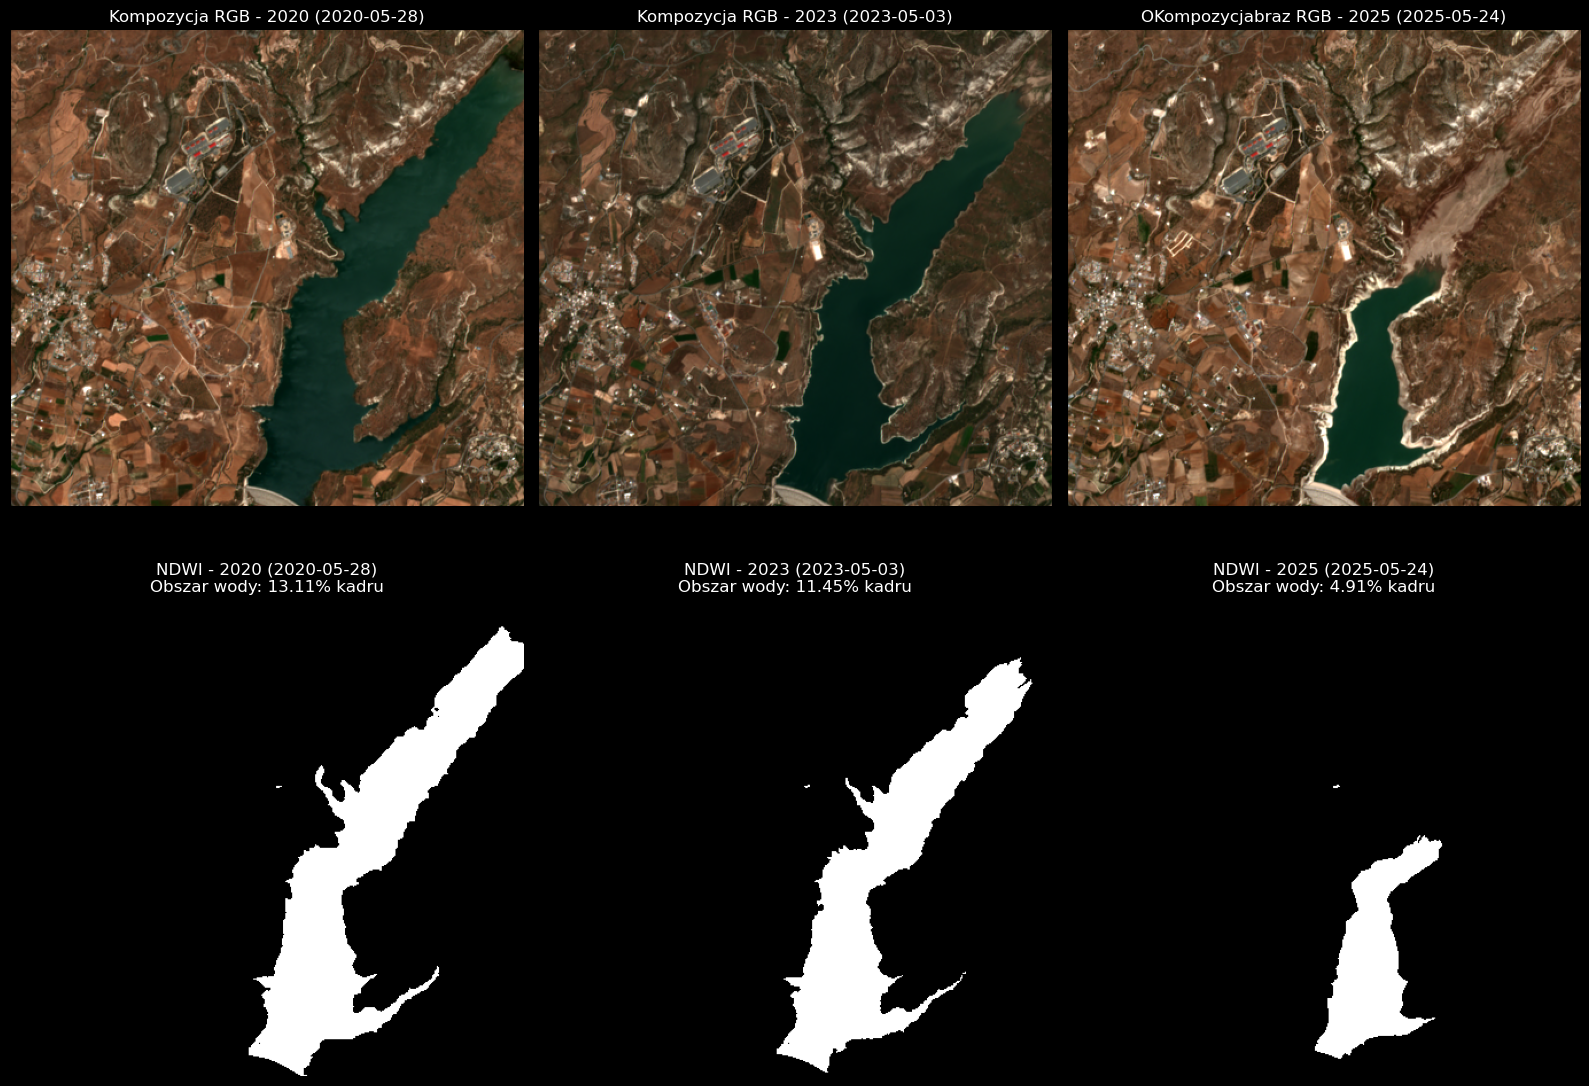

In [ ]:
date_1 = str(raster_objects["raster_1"]["StdTime"])[:10]
date_2 = str(raster_objects["raster_2"]["StdTime"])[:10]
date_3 = str(raster_objects["raster_3"]["StdTime"])[:10]

plt.style.use("dark_background")
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# RGB
axes[0, 0].imshow(rgb_1)
axes[0, 0].set_title(f"Kompozycja RGB - 2020 ({date_1})")
axes[0, 0].axis("off")

axes[0, 1].imshow(rgb_2)
axes[0, 1].set_title(f"Kompozycja RGB - 2023 ({date_2})")
axes[0, 1].axis("off")

axes[0, 2].imshow(rgb_3)
axes[0, 2].set_title(f"Kompozycja RGB - 2025 ({date_3})")
axes[0, 2].axis("off")

# NDWI
axes[1, 0].imshow(water_mask_1, cmap="grey") 
axes[1, 0].set_title(f"NDWI - 2020 ({date_1})\nObszar wody: {water_pct_1:.2f}% kadru")
axes[1, 0].axis("off")

axes[1, 1].imshow(water_mask_2, cmap="grey")
axes[1, 1].set_title(f"NDWI - 2023 ({date_2})\nObszar wody: {water_pct_2:.2f}% kadru")
axes[1, 1].axis("off")

axes[1, 2].imshow(water_mask_3, cmap="grey")  
axes[1, 2].set_title(f"NDWI - 2025 ({date_3})\nObszar wody: {water_pct_3:.2f}% kadru")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

Wykres liniowy zmian w czasie

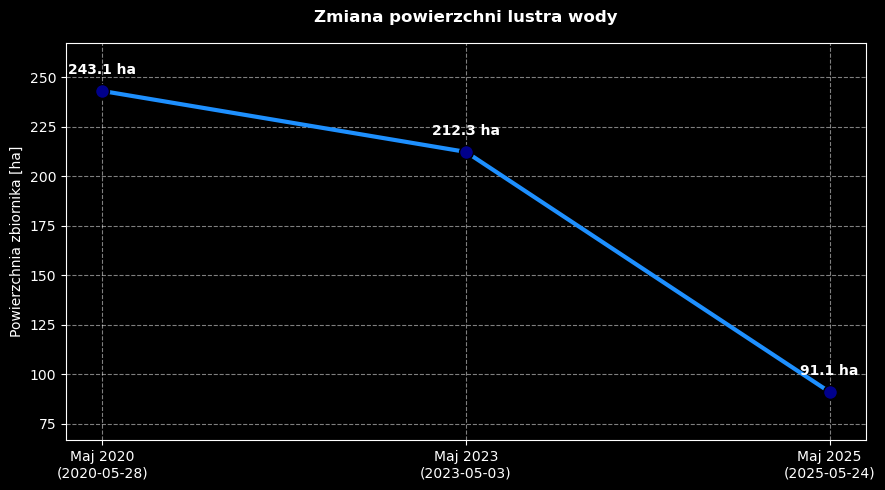

In [11]:
valid_pixels_1 = np.sum(valid_1)
valid_pixels_2 = np.sum(valid_2)
valid_pixels_3 = np.sum(valid_3)

area_ha_1 = ((water_pct_1 * valid_pixels_1) / 100.0) * 0.01
area_ha_2 = ((water_pct_2 * valid_pixels_2) / 100.0) * 0.01
area_ha_3 = ((water_pct_3 * valid_pixels_3) / 100.0) * 0.01

plt.figure(figsize=(9, 5))

lata_etykiety = [f"Maj 2020\n({date_1})", f"Maj 2023\n({date_2})", f"Maj 2025\n({date_3})"]
wartosci_ha = [area_ha_1, area_ha_2, area_ha_3]

# linia trendu z kropkami
plt.plot(lata_etykiety, wartosci_ha, color="#1E90FF", linestyle="-", linewidth=3, 
         marker="o", markersize=10, markerfacecolor="darkblue", markeredgecolor="black", zorder=3)

# podpisy z wartością nad punktami (ha)
for i, txt in enumerate(wartosci_ha):
    plt.annotate(f"{txt:.1f} ha", (lata_etykiety[i], wartosci_ha[i]), 
                 textcoords="offset points", xytext=(0, 12), ha='center', fontweight='bold', fontsize=10)

plt.title("Zmiana powierzchni lustra wody", fontsize=12, fontweight='bold', pad=15)
plt.ylabel("Powierzchnia zbiornika [ha]", fontsize=10)

# dynamiczny margines dla osi Y, żeby napisy nie uciekały poza wykres
plt.ylim(min(wartosci_ha) - (max(wartosci_ha)*0.1), max(wartosci_ha) + (max(wartosci_ha)*0.1)) 

plt.grid(True, linestyle='--', alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

Analiza wykresu wskazuje na przyspieszającą degradację powierzchni zbiornika. Drastyczne załamanie linii trendu w okresie 2023-2025 koreluje się z odnotowanymi długotrwałymi deficytami opadów, co wymusza zarządzanie zasobami wodnymi w regionie.

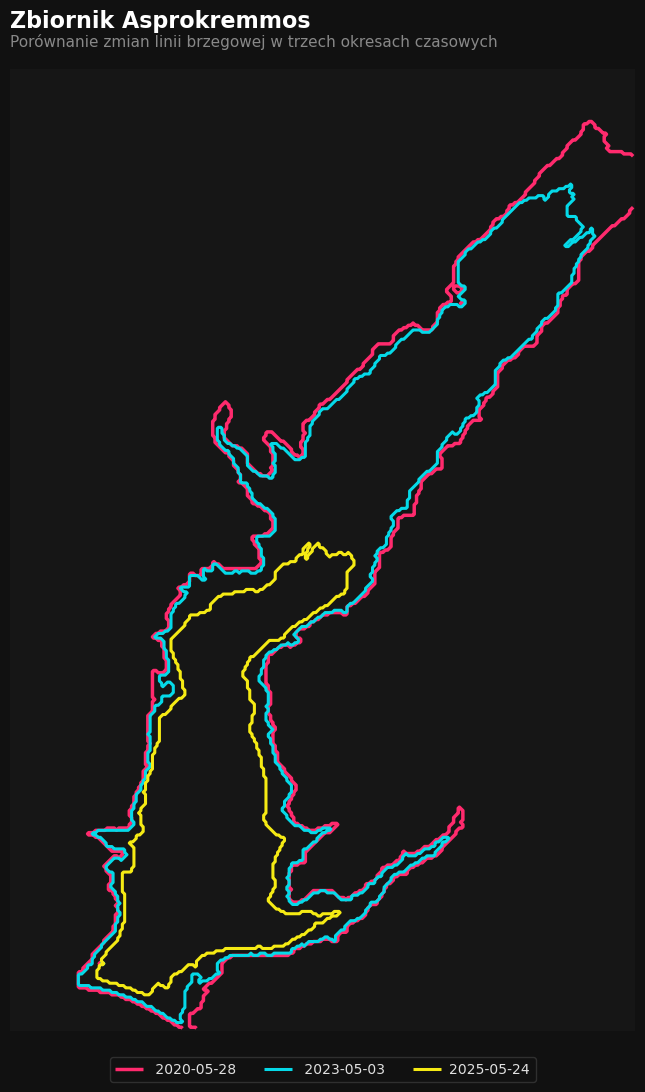

In [12]:
def remove_small_objects(mask, min_size=150):
    """
    Funkcja identyfikuje odizolowane obiekty na masce i usuwa te, 
    których powierzchnia jest mniejsza niż min_size (w pikselach).
    """
    labeled_array, num_features = ndimage.label(mask)
    bincounts = np.bincount(labeled_array.ravel())
    size_mask = (bincounts >= min_size)
    size_mask[0] = 0  # ignorujemy tło
    cleaned_mask = size_mask[labeled_array]
    return cleaned_mask.astype(float)

# odszumianie
ultra_clean_1 = remove_small_objects(water_mask_1, min_size=150)
ultra_clean_2 = remove_small_objects(water_mask_2, min_size=150)
ultra_clean_3 = remove_small_objects(water_mask_3, min_size=150)

# wyśrodkowanie
y_indices, x_indices = np.where((ultra_clean_1 > 0) | (ultra_clean_2 > 0) | (ultra_clean_3 > 0))

if len(x_indices) > 0 and len(y_indices) > 0:
    pad = 30  
    x_min, x_max = max(0, x_indices.min() - pad), min(ultra_clean_1.shape[1], x_indices.max() + pad)
    y_min, y_max = max(0, y_indices.min() - pad), min(ultra_clean_1.shape[0], y_indices.max() + pad)
else:
    x_min, x_max = 0, ultra_clean_1.shape[1]
    y_min, y_max = 0, ultra_clean_1.shape[0]

fig, ax = plt.subplots(figsize=(8, 11), facecolor="#111111")
ax.set_facecolor("#161616") 

# rysowanie konturów
contour_1 = ax.contour(ultra_clean_1, levels=[0.5], colors="#FF2A6D", linewidths=2.5) 
contour_2 = ax.contour(ultra_clean_2, levels=[0.5], colors="#05D9E8", linewidths=2.2) 
contour_3 = ax.contour(ultra_clean_3, levels=[0.5], colors="#F5EA14", linewidths=2.2) 

# blokada proporcji i kadrowanie
ax.set_aspect('equal')  
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_max, y_min) 

# ukrywanie osi
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# tytuł i podtytuł
plt.title("Zbiornik Asprokremmos", fontsize=16, fontweight='bold', pad=30, color="white", loc="left")

ax.text(0.0, 1.02, "Porównanie zmian linii brzegowej w trzech okresach czasowych", transform=ax.transAxes, fontsize=11, color="#888888", va="bottom", ha="left")

# przygotowanie legendy
line_1, _ = contour_1.legend_elements()
line_2, _ = contour_2.legend_elements()
line_3, _ = contour_3.legend_elements()
lines = [line_1[0], line_2[0], line_3[0]]
labels = [f" {date_1}", f" {date_2}", f"{date_3}"]

# legenda wsunięta pod wykres
legend = ax.legend(
    lines, labels, 
    loc="upper center",       
    bbox_to_anchor=(0.5, -0.02), # ujemna wartość wysuwa legendę pod spód mapy
    ncol=3,                   
    fontsize=10, 
    frameon=True,
    facecolor="#111111", 
    edgecolor="#333333",  
    framealpha=0.9,
    handletextpad=0.6,
    columnspacing=2.0
)

for text in legend.get_texts():
    text.set_color("#E0E0E0")

plt.tight_layout()
plt.show()

# Krok 7. Podsumowanie
#### Wnioski
Wykres przedstawia porównanie poziomu wody w trzech analizowanych latach: 2020, 2023 oraz 2025. Dostrzegalne są wyraźne zmiany linii brzegowej, które najbardziej widoczne są w 2025.

W 2020 zasięg zbiornika *Asprokremmos* był największy ze wszystkich analizowanych. Szczególnie widoczne to jest w północnej części, w miejscu ujścia rzeki *Xeropotamos*. W porównaniu z 2020 rokiem zmiany w 2023 roku są więc niewielkie. Poza wspomnianym północnym fragmentem widoczne są miejsca spływu wód opadowych z okolicznych wzgórz. Można to dostrzec na charakterystycznych odnogach w południowo-wschodniej oraz środkowo-zachodniej części.

Największe zmiany obserwowane są w roku 2025. Poziom wody widocznie się zmniejszył praktycznie w każdym miejscu, szczególnie mocno w północnej części, gdzie jezioro widocznie zmniejszyło się. Miało to związek z ekstremalną suszą trwającą od paru lat. Sama analiza zmian poziomu wody dostarcza pośrednio informacji topologicznej o budowie doliny - która w północnej części jest bardziej płaska, w porównaniu z południowymi krańcami zwieńczonymi tamą, gdzie występuje większy spadek, przez co woda utrzymuje się tam dłużej.


#### Ograniczenia metody

Analiza danych satelitarnych pod kątem zmian zasobów wodnych jest efektywna, ale posiada specyficzne ograniczenia, które użytkownik powinien wziąć pod uwagę, aby uniknąć błędnych interpretacji wyników.

* **Rozdzielczość czasowa i chmury**: Mimo 5-dniowego cyklu rewizyty, możliwe jest występowanie dużego zachmurzenia zwłaszcza na teranach, na których obecne jest intensywne parowanie (np. strefa równikowa). Chmury i ich cienie są dla sensorów MSI nieprzezroczyste, co powoduje luki w szeregach czasowych. Jeśli w danym dniu pomiarowym wystąpiło zachmurzenie nad zbiornikiem, nie otrzymasz jakościowych danych dla tego konkretnego ujęcia.

* **Efekt "mieszanego piksela"**:
Na obrzeżach zbiornika jeden piksel (10x10 m) może zawierać zarówno wodę, jak i grunt. W procesie automatycznej klasyfikacji może to prowadzić do niedoszacowania rzeczywistego zasięgu wody w okresach, gdy brzeg jest bardzo postrzępiony.

* **Wpływ jakości wody**: Metody oparte na reflektancji (takie jak indeksy wodne) mogą dawać przekłamane wyniki w przypadku zbiorników o bardzo wysokim stopniu zamulenia lub silnym zakwicie glonów, co zmienia parametry optyczne wody i może "oszukać" algorytm wykrywający wodę.

#### Propozycje poprawek i optymalizacji

* **Zastosowanie kompozycji czasowych**: Zamiast analizować pojedyncze obrazy, warto tworzyć **kompozyty miesięczne** (np. wyliczanie mediany dla danego miesiąca). Eliminuje to wpływ chmur oraz chwilowych zakłóceń, takich jak odbłyski słońca na powierzchni wody, dając czystszy obraz średniego stanu wody w danym okresie.

* **Wykorzystanie danych SAR (Sentinel-1)**: Ciągłość pomiarowa niezależnie od pogody można osiągnąć poprzez fuzję danych optycznych (Sentinel-2) z danymi radarowymi (Sentinel-1). Radar nie jest ograniczony wizualnie przez chmury, dlatego może służyć jako uzupełnienie pomiarów.

* **Dynamiczne progowanie**: Zamiast stosować stały próg możliwe jest wykorzystanie algorytmu automatycznego dopasowania progu detekcji wody dla aktualnych warunków oświetleniowych konkretnego zdjęcia.


#### Uwagi końcowe dla użytkownika
Praca z danymi satelitarnymi pobieranymi przez API daje ogromną przewagę czasową oraz wydajnościową w porównaniu z ręcznym pobieraniem, przetwarzaniem i testowaniem kolejnych plików. W przykładzie przedstawiono tylko jeden z wielu możliwych do wyliczenia indeksów, które mogą posłużyć do analizy różnych zjawisk zachodzących na powierzchni Ziemi, ale również w atmosferze.

W formułowaniu wniosków z obserwacji konieczne jest zapoznanie się z konteksem analizy i porównanie jej wyników z dostępnymi danymi i badaniami naukowymi. Również w tym przypadku zbiornik Asprokremmos jest doskonałym przykładem. Na podstawie obniżania się poziomu wody można wyciągnąć wniosek o podleganiu w tym rejonie czynnikom klimatycznym, takim jak zmniejszenie liczby opadów oraz wzrostowi średniej temperatury powietrza. Należy jednak pamiętać, że wpływ na stan wody mogą mieć także inne czynniki. Asprokremmos jest sztucznym zbiornikiem, z tamą na swoim południowym krańcu. Ze względu na występujące na tym terenie rolnictwo bananów, winogron oraz tytoniu zbiornik podlega zarządzaniu hydrologicznemu - wypuszczenie wody jest planowym zabiegiem w celu nawodnienia upraw.